In [1]:
import pandas as pd
import numpy as np
from statsmodels.stats.weightstats import ztest
from scipy.stats import skew , f_oneway , pearsonr, ttest_rel, chi2_contingency,spearmanr,shapiro,levene
import seaborn as sns
import matplotlib.pyplot as plt



In [2]:
file_path="C:/Users/haank/Downloads/Tampa 100 Video.xlsx"
data_24=pd.read_excel(file_path,sheet_name='2024')
data_23=pd.read_excel(file_path,sheet_name='2023')

In [3]:
data_24.head()

,Place,First_Name,Last_Name,City,State,Age,Gender,Time
0,1,Lucas,Vidal,Cape Coral,FL,38,M,19:43:00
1,2,Brandon,Westover,Orlando,FL,45,M,21:15:00
2,3,Lucas,Hathaway,Atlanta,GA,34,M,23:31:36
3,4,Sage,Lyons,Sarasota,FL,27,F,23:37:05
4,5,Colin,Gotham,Land O Lakes,FL,30,M,"1 day, 0:43:02"


In [4]:
data_23.head()

,Place,First_Name,Last_Name,City,State,Age,Gender,Time
0,1,Mike,Alberts,Melbourne,FL,34,M,18:33:06
1,2,Matt,Clapper,NaN,USA,41,M,19:21:53
2,3,Sarah,Raaymakers,Odessa,FL,39,F,20:43:19
3,4,Nikki,Criscuolo,South Pasadena,FL,24,F,21:02:52
4,5,Nels,Matson,Bradenton,FL,41,M,21:21:08


In [5]:
data_24['full_name']=data_24['First_Name']+' '+data_24['Last_Name']
data_23['full_name']=data_23['First_Name']+' '+data_23['Last_Name']


In [6]:
data_24.head()

,Place,First_Name,Last_Name,City,State,Age,Gender,Time,full_name
0,1,Lucas,Vidal,Cape Coral,FL,38,M,19:43:00,Lucas Vidal
1,2,Brandon,Westover,Orlando,FL,45,M,21:15:00,Brandon Westover
2,3,Lucas,Hathaway,Atlanta,GA,34,M,23:31:36,Lucas Hathaway
3,4,Sage,Lyons,Sarasota,FL,27,F,23:37:05,Sage Lyons
4,5,Colin,Gotham,Land O Lakes,FL,30,M,"1 day, 0:43:02",Colin Gotham


In [7]:
data_24.drop(['First_Name','Last_Name'],axis=1,inplace=True)
data_23.drop(['First_Name','Last_Name'],axis=1,inplace=True)

In [8]:
data_24.head()

,Place,City,State,Age,Gender,Time,full_name
0,1,Cape Coral,FL,38,M,19:43:00,Lucas Vidal
1,2,Orlando,FL,45,M,21:15:00,Brandon Westover
2,3,Atlanta,GA,34,M,23:31:36,Lucas Hathaway
3,4,Sarasota,FL,27,F,23:37:05,Sage Lyons
4,5,Land O Lakes,FL,30,M,"1 day, 0:43:02",Colin Gotham


In [9]:
data_23.head()

,Place,City,State,Age,Gender,Time,full_name
0,1,Melbourne,FL,34,M,18:33:06,Mike Alberts
1,2,NaN,USA,41,M,19:21:53,Matt Clapper
2,3,Odessa,FL,39,F,20:43:19,Sarah Raaymakers
3,4,South Pasadena,FL,24,F,21:02:52,Nikki Criscuolo
4,5,Bradenton,FL,41,M,21:21:08,Nels Matson


In [10]:
data_23[data_23['Time']=='Did Not Finish']

,Place,City,State,Age,Gender,Time,full_name
48,0,Brooksville,FL,62,M,Did Not Finish,Andy Mathews
49,0,Odessa,FL,61,F,Did Not Finish,Pam Dickens
50,0,New Smyrna Beach,FL,61,M,Did Not Finish,Chris Goodreau
51,0,Brooksville,FL,55,F,Did Not Finish,Laura Cole
52,0,Tampa,FL,81,M,Did Not Finish,Haywood Crowder
53,0,Tampa,FL,41,M,Did Not Finish,Matthew Massuto
54,0,Lk Wls,FL,46,F,Did Not Finish,Natashiia Cosgrove
55,0,Auburndale,FL,69,F,Did Not Finish,Roxanne Youngs
56,0,Winnipeg,MB,41,M,Did Not Finish,Jeremy Welwood
57,0,Tampa,FL,48,M,Did Not Finish,Ben Montgomery


In [11]:
data_23_fin=data_23[data_23['Time']!='Did Not Finish'].copy()
data_24_fin=data_24[data_24['Time']!='Did Not Finish'].copy()

In [12]:
data_23_dnf=data_23[data_23['Time']=='Did Not Finish'].copy()
data_24_dnf=data_24[data_24['Time']=='Did Not Finish'].copy()

In [13]:
data_23_dnf.drop(['Place','Time'],axis=1,inplace=True)
data_24_dnf.drop(['Place','Time'],axis=1,inplace=True)

In [14]:
data_23_fin['Time'] = data_23_fin["Time"].astype(str)
data_24_fin['Time'] = data_24_fin["Time"].astype(str)

In [15]:
data_23_fin['Time_Delta'] = pd.to_timedelta(data_23_fin['Time'],errors="coerce")
data_24_fin['Time_Delta'] = pd.to_timedelta(data_24_fin['Time'],errors="coerce")

In [16]:
data_23_fin['race_minutes'] = data_23_fin['Time_Delta'].dt.total_seconds()/60
data_24_fin['race_minutes'] = data_24_fin['Time_Delta'].dt.total_seconds()/60

In [17]:
data_23_fin.drop(['Time_Delta'],axis=1,inplace=True)
data_24_fin.drop(['Time_Delta'],axis=1,inplace=True)

In [18]:
data_23_fin.head()

,Place,City,State,Age,Gender,Time,full_name,race_minutes
0,1,Melbourne,FL,34,M,18:33:06,Mike Alberts,1113.100000
1,2,NaN,USA,41,M,19:21:53,Matt Clapper,1161.883333
2,3,Odessa,FL,39,F,20:43:19,Sarah Raaymakers,1243.316667
3,4,South Pasadena,FL,24,F,21:02:52,Nikki Criscuolo,1262.866667
4,5,Bradenton,FL,41,M,21:21:08,Nels Matson,1281.133333


In [19]:
data_24_fin.head()

,Place,City,State,Age,Gender,Time,full_name,race_minutes
0,1,Cape Coral,FL,38,M,19:43:00,Lucas Vidal,1183.000000
1,2,Orlando,FL,45,M,21:15:00,Brandon Westover,1275.000000
2,3,Atlanta,GA,34,M,23:31:36,Lucas Hathaway,1411.600000
3,4,Sarasota,FL,27,F,23:37:05,Sage Lyons,1417.083333
4,5,Land O Lakes,FL,30,M,"1 day, 0:43:02",Colin Gotham,1483.033333


In [20]:
data_23_fin['race_minutes'].mean()

np.float64(1726.4187499999998)

In [21]:
data_24_fin['race_minutes'].mean()

np.float64(1809.1434959349592)

In [22]:
data_23_fin['race_minutes'].median()

1732.7333333333333

In [23]:
data_24_fin['race_minutes'].median()

1865.0

In [24]:
data_23_fin['race_minutes'].std()

272.7764213772832

In [25]:
data_24_fin['race_minutes'].std()

247.9496065477724

In [26]:
data_23_fin['full_name'].count()/(data_23_fin['full_name'].count() + data_23_dnf['full_name'].count())

np.float64(0.6575342465753424)

In [27]:
data_24_fin['full_name'].count()/(data_24_fin['full_name'].count() + data_24_dnf['full_name'].count())

np.float64(0.5394736842105263)

In [28]:
data_23['State'].value_counts().head()

State
FL     59
USA     3
NC      2
AL      2
CA      1
Name: count, dtype: int64

In [29]:
data_23['City'].value_counts().head()

City
Tampa         8
Clearwater    5
Odessa        4
Palmetto      3
Orlando       3
Name: count, dtype: int64

In [30]:
data_24['State'].value_counts().head()

State
FL    56
VA     3
GA     2
NC     2
OH     2
Name: count, dtype: int64

In [31]:
data_24['City'].value_counts().head()

City
Tampa             9
Clearwater        3
Ocala             3
Virginia Beach    2
Plant City        2
Name: count, dtype: int64

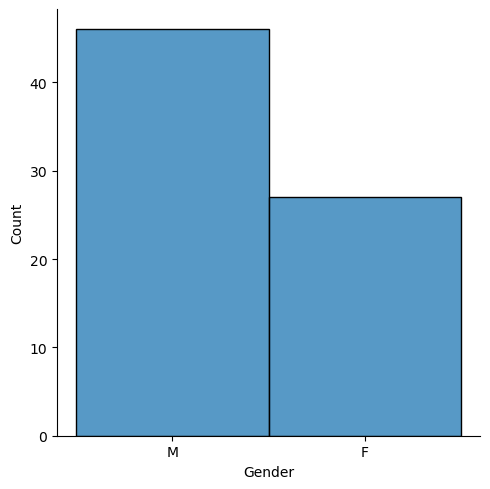

In [32]:
sns.displot(data_23,x='Gender')

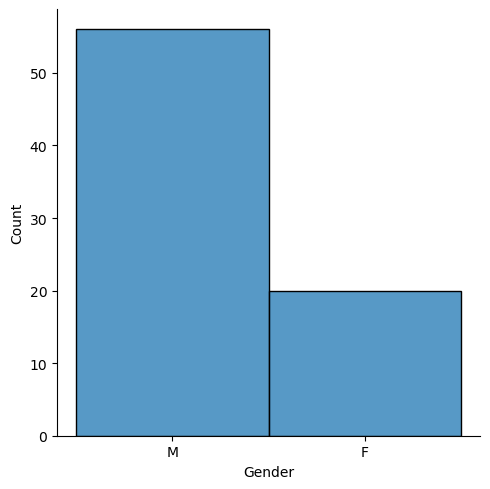

In [33]:
sns.displot(data_24,x='Gender')

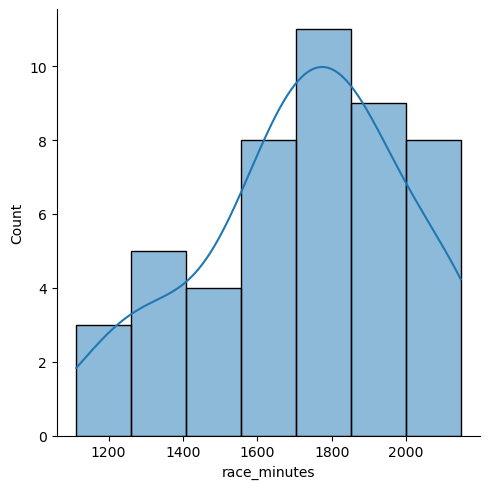

In [34]:
sns.displot(data_23_fin['race_minutes'],kde=True)

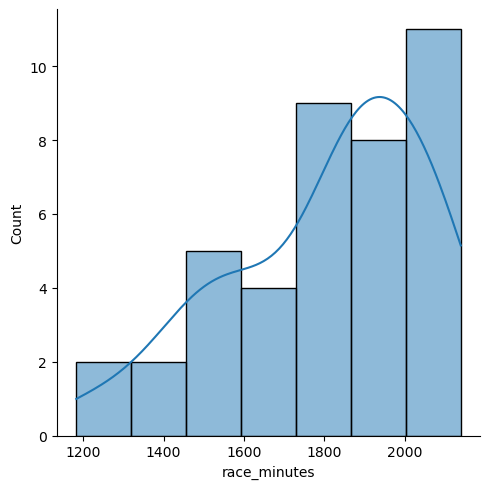

In [35]:
sns.displot(data_24_fin['race_minutes'],kde=True)

In [36]:
skew_23 = skew(data_23_fin['race_minutes'])

In [37]:
skew_24 = skew(data_24_fin['race_minutes'])

In [38]:
print(skew_23)
print(skew_24)

-0.40822297476957614
-0.7258344180321886


In [39]:
male_fin_23 = data_23_fin[data_23_fin['Gender']=='M'].copy()
female_fin_23 = data_23_fin[data_23_fin['Gender']=='F'].copy()
male_fin_24 = data_24_fin[data_24_fin['Gender']=='M'].copy()
female_fin_24 = data_24_fin[data_24_fin['Gender']=='F'].copy()

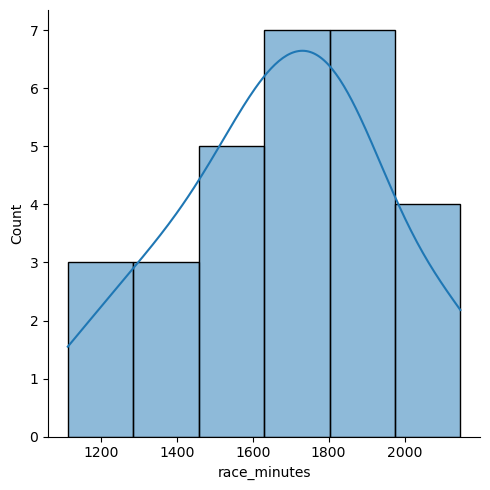

In [40]:
sns.displot(male_fin_23['race_minutes'],kde=True)

In [41]:
male_fin_23.head()

,Place,City,State,Age,Gender,Time,full_name,race_minutes
0,1,Melbourne,FL,34,M,18:33:06,Mike Alberts,1113.100000
1,2,NaN,USA,41,M,19:21:53,Matt Clapper,1161.883333
4,5,Bradenton,FL,41,M,21:21:08,Nels Matson,1281.133333
5,6,Odessa,FL,57,M,22:14:05,Joe Tumminia,1334.083333
6,7,Sarasota,FL,36,M,22:34:35,Tylor Bates,1354.583333


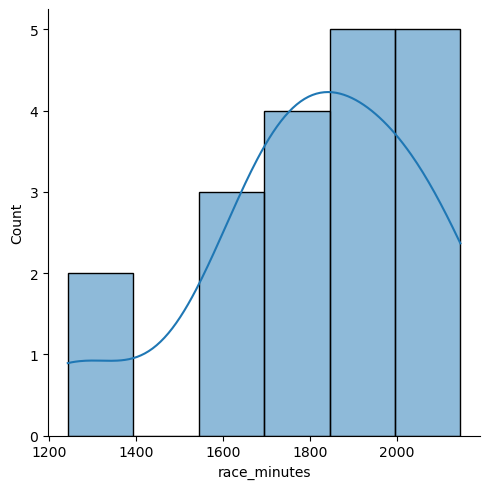

In [42]:
sns.displot(female_fin_23['race_minutes'],kde=True)

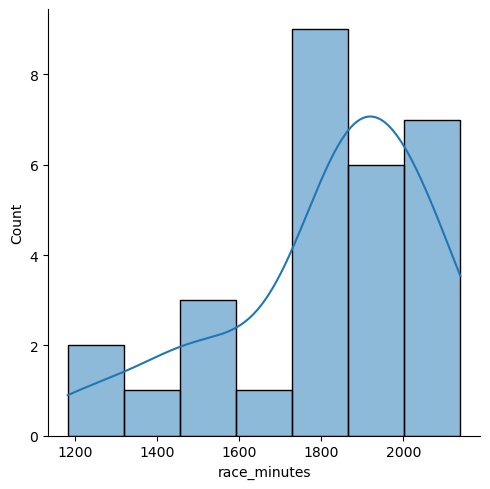

In [43]:
sns.displot(male_fin_24['race_minutes'],kde=True)

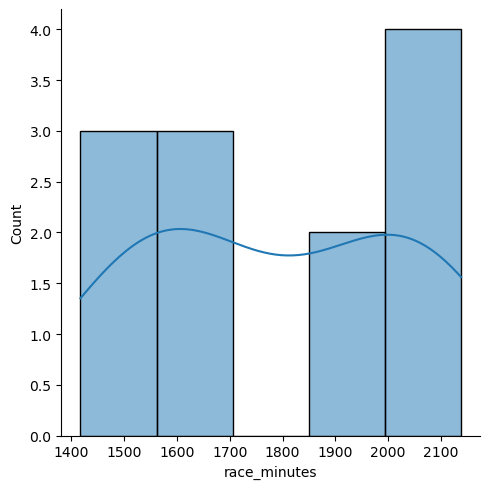

In [44]:
sns.displot(female_fin_24['race_minutes'],kde=True)

In [45]:
combined_data = pd.DataFrame({
    'age': pd.concat([
        data_24_fin['Age'],
        data_24_dnf['Age'],
        data_23_fin['Age'],
        data_23_dnf['Age']
    ]),
    'category': (
        ['2024 finishers'] * len(data_24_fin['Age']) +
        ['2024 dnf'] * len(data_24_dnf['Age']) +
        ['2023 finishers'] * len(data_23_fin['Age']) +  
        ['2023 dnf'] * len(data_23_dnf['Age'])          
    )
})

In [46]:
print(combined_data)

    age        category
0    38  2024 finishers
1    45  2024 finishers
2    34  2024 finishers
3    27  2024 finishers
4    30  2024 finishers
..  ...             ...
68   36        2023 dnf
69   50        2023 dnf
70   50        2023 dnf
71   50        2023 dnf
72   39        2023 dnf

[149 rows x 2 columns]


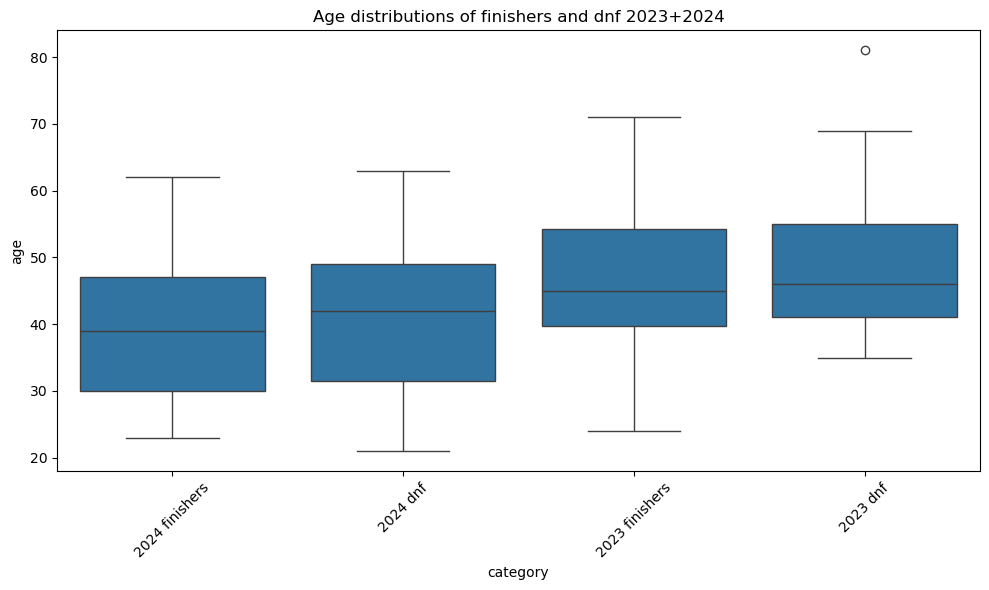

In [47]:
plt.figure(figsize=(10,6))
sns.boxplot(data=combined_data,x='category',y='age')

plt.title('Age distributions of finishers and dnf 2023+2024')
plt.xlabel('category')
plt.ylabel('age')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Axes: xlabel='Gender', ylabel='race_minutes'>

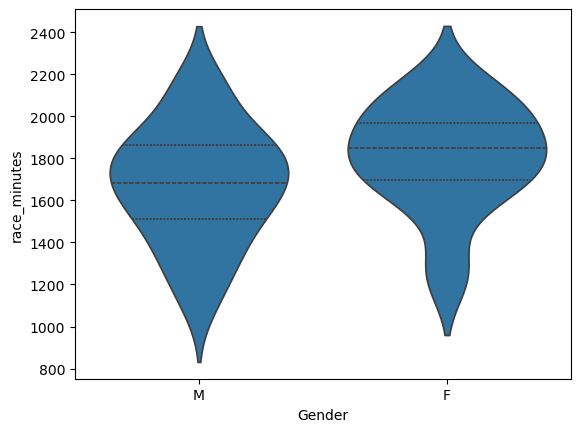

In [48]:
sns.violinplot(data=data_23_fin,x='Gender',y='race_minutes',inner='quartiles')

<Axes: xlabel='Gender', ylabel='race_minutes'>

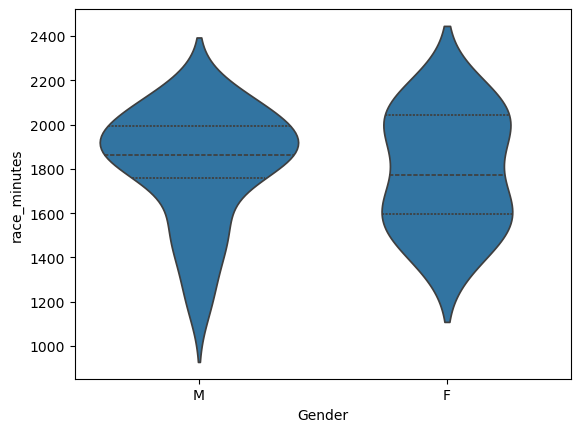

In [49]:
sns.violinplot(data=data_24_fin,x='Gender',y='race_minutes',inner='quartiles')

<Axes: xlabel='Age', ylabel='race_minutes'>

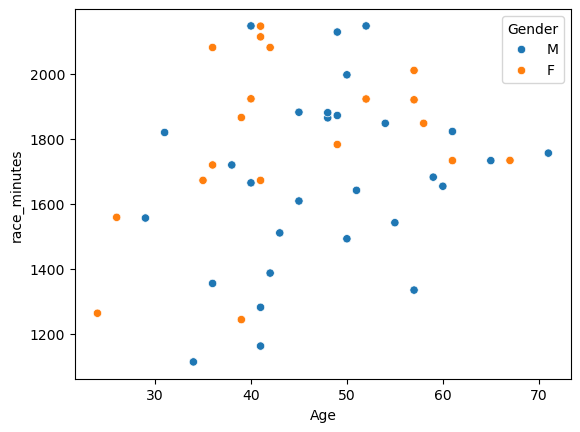

In [50]:
sns.scatterplot(data=data_23_fin,x='Age',y='race_minutes',hue='Gender')

<Axes: xlabel='Age', ylabel='race_minutes'>

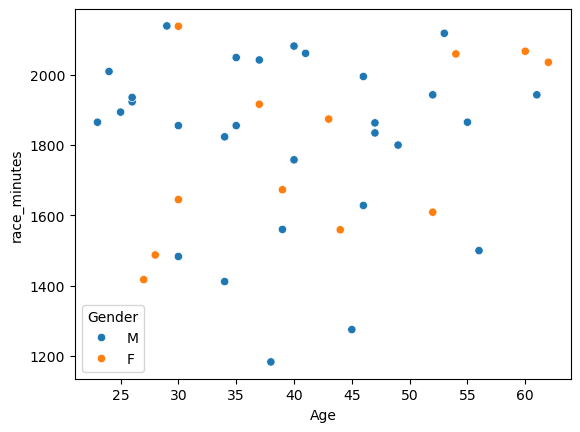

In [51]:
sns.scatterplot(data=data_24_fin,x='Age',y='race_minutes',hue='Gender')

In [52]:
_ ,p_age_23 = shapiro(data_23_fin['Age'])

In [53]:
print(p_age_23)

0.7440999746357332


In [54]:
_ ,p_race_23 = shapiro(data_23_fin['race_minutes'])
print(p_race_23)

0.11799266916670359


In [55]:
corr_23, _ =pearsonr(data_23_fin['Age'],data_23_fin['race_minutes'])
print(corr_23)

0.23654847480834612


In [56]:
corr_24, _ =pearsonr(data_24_fin['Age'],data_24_fin['race_minutes'])
print(corr_24)

0.1094699840563637


In [57]:
_ ,p_race_24 = shapiro(data_24_fin['race_minutes'])
print(p_race_24)

0.012151833574466234


In [58]:
corr_24, _ =spearmanr(data_24_fin['Age'],data_24_fin['race_minutes'])
print(corr_24)

0.10327392870461473


In [59]:
#test


In [60]:
alpha = 0.05


In [61]:
#two sample ztest
#compare 23 and 24 looking at the times

race_24_times=data_24_fin['race_minutes']
race_23_times=data_23_fin['race_minutes']

In [62]:
z_score,p_value=ztest(race_24_times,race_23_times,alternative='larger')
print(z_score)
print(p_value)

1.486704861264319
0.06854638910805894


In [63]:
if p_value<alpha:
    print(f'Reject the null hypothesis')
else:
    print(f'Fail to reject null hypothesis because pvalue is ',{p_value})

Fail to reject null hypothesis because pvalue is  {np.float64(0.06854638910805894)}


In [64]:
#paired t test competed in 2023 vs 2024

merged_data = pd.merge(
    data_23_fin, data_24_fin, on="full_name", suffixes=("_2023", "_2024")
)


In [65]:
merged_data.head()

,Place_2023,City_2023,State_2023,Age_2023,Gender_2023,Time_2023,full_name,race_minutes_2023,Place_2024,City_2024,State_2024,Age_2024,Gender_2024,Time_2024,race_minutes_2024
0,9,Los angeles,CA,50,M,"1 day, 0:52:00",David Paske,1492.000000,24,Los Angeles,CA,25,M,"1 day, 7:33:47",1893.783333
1,11,St Petersburg,FL,55,M,"1 day, 1:41:28",Doug Mayle,1541.466667,7,St. Petersburg,FL,56,M,"1 day, 0:59:46",1499.766667
2,13,Sarasota,FL,26,F,"1 day, 1:57:53",Sage Lyons,1557.883333,4,Sarasota,FL,27,F,23:37:05,1417.083333


In [66]:
merged_data['time_diff'] = merged_data['race_minutes_2023'] - merged_data['race_minutes_2024']

In [67]:
_ , p_race_time_diff = shapiro(merged_data['time_diff'])
print(p_race_time_diff)

0.3291542154605184


In [68]:
race_24 = merged_data['race_minutes_2024']
race_23 = merged_data['race_minutes_2023']
race_23.mean()
race_24.mean()
t_stat,p_value=ttest_rel(race_24,race_23)
print(p_value)
if p_value<alpha:
    print(f'Reject the null hypothesis')
else:
    print(f'Fail to reject null hypothesis because pvalue is ',{p_value})

0.7040438895013723
Fail to reject null hypothesis because pvalue is  {np.float64(0.7040438895013723)}


In [69]:
#ANNOVA by age 
data_24_fin['age_bucket'] = (data_24_fin['Age']//10 * 10).astype(str)

In [70]:
print(data_24_fin['age_bucket'])

0     30
1     40
2     30
3     20
4     30
5     20
6     50
7     40
8     30
9     50
10    40
11    30
12    30
13    40
14    40
15    30
16    40
17    30
18    30
19    40
20    20
21    50
22    40
23    20
24    30
25    20
26    20
27    60
28    50
29    40
30    20
31    60
32    30
33    30
34    50
35    40
36    60
37    40
38    50
39    30
40    20
Name: age_bucket, dtype: object


In [71]:
race_times_age=data_24_fin.groupby('age_bucket')['race_minutes'].apply(list)

In [72]:
_,levene_p_value = levene(*race_times_age)

In [73]:
print(levene_p_value)

0.5613814303440565


In [75]:
shapiro = {}

for age_bucket,race_times in zip(data_24_fin['age_bucket'].unique(),race_times_age):
    stat,p_value=shapiro(race_times)
    shapiro_results[age_bucket]=(stat,p_value)

TypeError: 'dict' object is not callable